In [1]:
import pandas as pd
import time
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score



# # 2. Define a benchmarking function
# def benchmark_algorithm(model, name, data):
#     print(f"Starting {name}...")
#     start_time = time.time()
    
#     # Run the clustering
#     labels = model.fit_predict(data)
    
#     end_time = time.time()
#     execution_time = end_time - start_time
    
#     # Calculate cluster quality (ignoring DBSCAN noise points if necessary)
#     n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
#     if n_clusters > 1:
#         score = silhouette_score(data, labels)
#     else:
#         score = -1.0 # Failed to find meaningful clusters
        
#     print(f"--- Results for {name} ---")
#     print(f"Clusters Found: {n_clusters}")
#     print(f"Execution Time: {execution_time:.2f} seconds")
#     print(f"Silhouette Score: {score:.4f}\n")
    
#     return labels

# # 3. Run the Benchmarks

# # Algorithm A: K-Means (Centroid-based)
# # We will hardcode k=3 for a direct 1-to-1 comparison between algorithms
# kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
# df['KMeans_Labels'] = benchmark_algorithm(kmeans_model, "K-Means (k=3)", df)

# # # Algorithm B: Agglomerative (Hierarchical/Distance-based)
# # hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
# # df['Hierarchical_Labels'] = benchmark_algorithm(hierarchical_model, "Hierarchical (k=3)", df)

# # # Algorithm C: DBSCAN (Density-based)
# # # Density often breaks completely in high dimensions. We use a very high eps to compensate.
# # dbscan_model = DBSCAN(eps=50.0, min_samples=3) 
# # df['DBSCAN_Labels'] = benchmark_algorithm(dbscan_model, "DBSCAN (eps=50)", df)

In [4]:
clinical = pd.read_csv('../data/processed/clinical_lihc_pd_filtered_tumor.csv', index_col=0)
clinical

,sample,sample_type.samples,tissue_type.samples,ajcc_pathologic_stage.diagnoses,gender.demographic,race.demographic,vital_status.demographic,tissue_source_site_id.tissue_source_site,name.tissue_source_site
0,TCGA-DD-A73C-01A,Primary Tumor,Tumor,Stage IIIA,female,white,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
1,TCGA-5C-AAPD-01A,Primary Tumor,Tumor,Stage II,male,asian,Alive,994ff94f-5d44-5de6-908b-dea33dca2a3d,Cureline
2,TCGA-ZS-A9CE-01A,Primary Tumor,Tumor,Stage II,female,white,Alive,33a38997-77be-52dc-b79d-890d8d4b792b,Tayside Tissue Bank
3,TCGA-HP-A5N0-01A,Primary Tumor,Tumor,Unknown,female,not reported,Dead,b521e8d8-2b93-5a14-9fd0-ece883fd1327,Ontario Institute for Cancer Research (OICR)
4,TCGA-DD-AAVQ-01A,Primary Tumor,Tumor,Stage I,male,asian,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
...,...,...,...,...,...,...,...,...,...
434,TCGA-DD-A73E-01A,Primary Tumor,Tumor,Stage I,male,white,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
435,TCGA-CC-A7IH-01A,Primary Tumor,Tumor,Stage IIIA,male,asian,Alive,be652f28-50ec-5d4e-bc42-79a304ee03db,ILSBio
436,TCGA-BW-A5NO-01A,Primary Tumor,Tumor,Stage IIIA,male,black or african american,Alive,0e691470-b18b-5803-9e4a-ee2cfbaae7b4,St. Joseph's Medical Center-(MD)
437,TCGA-2Y-A9H9-01A,Primary Tumor,Tumor,Stage I,male,white,Alive,33e340f9-a97a-56eb-a3e6-aad831681cb4,Moffitt Cancer Center


In [20]:
clinical_all = pd.read_csv('../data/processed/clinical_lihc_pd_filtered_all.csv', index_col=0)
clinical_all

,sample,sample_type.samples,tissue_type.samples,ajcc_pathologic_stage.diagnoses,gender.demographic,race.demographic,vital_status.demographic,tissue_source_site_id.tissue_source_site,name.tissue_source_site
0,TCGA-DD-A73C-01A,Primary Tumor,Tumor,Stage IIIA,female,white,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
1,TCGA-5C-AAPD-01A,Primary Tumor,Tumor,Stage II,male,asian,Alive,994ff94f-5d44-5de6-908b-dea33dca2a3d,Cureline
2,TCGA-ZS-A9CE-01A,Primary Tumor,Tumor,Stage II,female,white,Alive,33a38997-77be-52dc-b79d-890d8d4b792b,Tayside Tissue Bank
3,TCGA-HP-A5N0-01A,Primary Tumor,Tumor,Unknown,female,not reported,Dead,b521e8d8-2b93-5a14-9fd0-ece883fd1327,Ontario Institute for Cancer Research (OICR)
4,TCGA-DD-AAVQ-01A,Primary Tumor,Tumor,Stage I,male,asian,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
...,...,...,...,...,...,...,...,...,...
434,TCGA-DD-A73E-01A,Primary Tumor,Tumor,Stage I,male,white,Alive,c2eb5c30-93cc-5a99-b9e4-f676e35ed7f8,Mayo Clinic - Rochester
435,TCGA-CC-A7IH-01A,Primary Tumor,Tumor,Stage IIIA,male,asian,Alive,be652f28-50ec-5d4e-bc42-79a304ee03db,ILSBio
436,TCGA-BW-A5NO-01A,Primary Tumor,Tumor,Stage IIIA,male,black or african american,Alive,0e691470-b18b-5803-9e4a-ee2cfbaae7b4,St. Joseph's Medical Center-(MD)
437,TCGA-2Y-A9H9-01A,Primary Tumor,Tumor,Stage I,male,white,Alive,33e340f9-a97a-56eb-a3e6-aad831681cb4,Moffitt Cancer Center


In [5]:
# 1. Load your fully imputed, unreduced dataset
# Ensure this is the dataframe where NaNs have been removed/imputed!
print("Loading data...")
df = pd.read_csv('../data/processed/methylation_lihc_pd_tumor.csv', index_col=0)
print(f"Data loaded. Shape: {df.shape} (Samples, Features)\n")

Loading data...
Data loaded. Shape: (377, 383815) (Samples, Features)



In [7]:
df

,cg00000108,cg00000109,cg00000236,cg00000292,cg00000321,cg00000363,cg00000622,cg00000658,cg00000714,cg00000721,...,ctl_70664314,ctl_70700334,ctl_71670310,ctl_71678368,ctl_71718498,ctl_72748406,ctl_73635489,ctl_73784382,ctl_73794434,ctl_74666473
TCGA-DD-A73D-01A,0.117137,0.924546,0.943050,0.657382,0.076094,0.851907,0.014520,0.796828,0.408849,0.959089,...,0.016190,0.058347,0.963264,0.056226,0.109904,0.098351,0.066046,0.939816,0.955241,0.961276
TCGA-G3-A5SK-01A,0.428748,0.908687,0.918806,0.676207,0.198359,0.751913,0.014256,0.840600,0.167963,0.957603,...,0.017244,0.096494,0.956808,0.075496,0.095065,0.097984,0.088078,0.931223,0.946813,0.957117
TCGA-DD-AAD8-01A,0.164315,0.802248,0.855616,0.719729,0.121652,0.642324,0.011543,0.845569,0.113078,0.937181,...,0.026267,0.101110,0.912187,0.114697,0.111062,0.117661,0.110835,0.893607,0.792508,0.960780
TCGA-WX-AA47-01A,0.259369,0.913790,0.931874,0.792509,0.083664,0.800295,0.015096,0.822098,0.109717,0.947942,...,0.022311,0.105520,0.955789,0.060052,0.101830,0.100906,0.081402,0.934609,0.938779,0.969138
TCGA-DD-A1EL-01A,0.619059,0.844312,0.866817,0.527882,0.198699,0.709242,0.015173,0.929196,0.135481,0.780788,...,0.072262,0.080303,0.943996,0.051412,0.213589,0.052199,0.085660,0.936370,0.940137,0.959429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-RC-A7S9-01A,0.727903,0.917399,0.879191,0.498206,0.248408,0.859052,0.012922,0.864288,0.097928,0.929429,...,0.017357,0.062147,0.960526,0.056585,0.099479,0.102135,0.066599,0.934101,0.948080,0.963495
TCGA-CC-A9FS-01A,0.967289,0.891528,0.860259,0.945034,0.676335,0.754555,0.013039,0.840799,0.107899,0.933557,...,0.026578,0.091685,0.919480,0.098662,0.094480,0.110258,0.170863,0.852174,0.930500,0.967402
TCGA-DD-AAEB-01A,0.321233,0.869649,0.865454,0.610651,0.127981,0.860820,0.011846,0.846064,0.184822,0.273931,...,0.022636,0.091522,0.937423,0.093921,0.129181,0.117661,0.078684,0.896254,0.891230,0.959803
TCGA-EP-A3RK-01A,0.731066,0.876023,0.951141,0.853662,0.243828,0.721904,0.011956,0.845202,0.172222,0.957277,...,0.015384,0.065589,0.961302,0.058295,0.103602,0.091236,0.063071,0.949478,0.962490,0.960636


In [8]:


# Extract the methylation scores as our feature matrix (X)
X = df.values
X

array([[0.11713712, 0.9245458 , 0.94305014, ..., 0.93981558, 0.95524053,
        0.9612762 ],
       [0.42874771, 0.9086874 , 0.9188063 , ..., 0.93122289, 0.94681286,
        0.95711719],
       [0.16431493, 0.80224846, 0.85561589, ..., 0.89360726, 0.79250819,
        0.96078048],
       ...,
       [0.32123319, 0.86964927, 0.86545445, ..., 0.89625367, 0.89122993,
        0.95980268],
       [0.7310655 , 0.87602262, 0.95114052, ..., 0.94947806, 0.96248982,
        0.96063598],
       [0.72027619, 0.91773247, 0.907275  , ..., 0.95164916, 0.9591816 ,
        0.96825452]])

In [ ]:
# import numpy as np

# silhouette_scores = []
# # We typically test k from 2 up to a reasonable maximum (e.g., 10)
# # k=1 is not possible for silhouette analysis because it requires comparing intra- vs inter-cluster distances
# K_range = range(2, 11) 

# print("Running Silhouette Analysis...")
# for k in K_range:
#     # Initialize K-Means
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
#     # Fit the model and predict cluster labels
#     cluster_labels = kmeans.fit_predict(X)
    
#     # Calculate the silhouette score
#     score = silhouette_score(X, cluster_labels)
#     silhouette_scores.append(score)
    
#     print(f"For k = {k}, Silhouette Score: {score:.4f}")

# # Determine the best k (the one with the highest silhouette score)
# best_k = K_range[np.argmax(silhouette_scores)]
# print(f"\n--> The optimal number of clusters based on Silhouette Score is: {best_k}")

Running Silhouette Analysis...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For k = 2, Silhouette Score: 0.1809


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For k = 3, Silhouette Score: 0.1175


...

/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For k = 8, Silhouette Score: 0.0457


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For k = 9, Silhouette Score: 0.0357


KeyboardInterrupt: 

In [17]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")

# Now import the rest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Safely catch any hidden Infs or NaNs
if np.isinf(X).any() or np.isnan(X).any():
    print("Cleaning hidden Infs or NaNs...")
    X = np.nan_to_num(X, nan=np.nanmean(X), posinf=np.nanmax(X), neginf=np.nanmin(X))

# ---------------------------------------------------------
# 2. Scale the Data
# ---------------------------------------------------------
print("Scaling data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# 3. Apply PCA
# ---------------------------------------------------------
# print("Applying PCA...")
# n_comp = min(10000, X_scaled.shape[0]) 
# pca = PCA(n_components=n_comp, svd_solver='full', random_state=42)
# X_pca = pca.fit_transform(X_scaled)

# # Extra safety net just in case PCA creates tiny artifacts
# X_pca = np.nan_to_num(X_pca)

# print(f"Explained Variance by {n_comp} components: {sum(pca.explained_variance_ratio_):.2%}")

# ---------------------------------------------------------
# 4. Silhouette Analysis
# ---------------------------------------------------------
silhouette_scores = []
max_k = min(11, X_scaled.shape[0])
K_range = range(2, max_k) 

print("\nRunning Silhouette Analysis...")
for k in K_range:
    # BUG FIX: algorithm='lloyd' prevents the macOS Accelerate crash
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, algorithm='lloyd')
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    
    print(f"For k = {k}, Silhouette Score: {score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n--> The optimal number of clusters based on Silhouette Score is: {best_k}")

Scaling data...

Running Silhouette Analysis...
For k = 2, Silhouette Score: 0.0965
For k = 3, Silhouette Score: 0.0517
For k = 4, Silhouette Score: 0.0436
For k = 5, Silhouette Score: 0.0373
For k = 6, Silhouette Score: 0.0326
For k = 7, Silhouette Score: 0.0410
For k = 8, Silhouette Score: 0.0265
For k = 9, Silhouette Score: 0.0311
For k = 10, Silhouette Score: 0.0140

--> The optimal number of clusters based on Silhouette Score is: 2


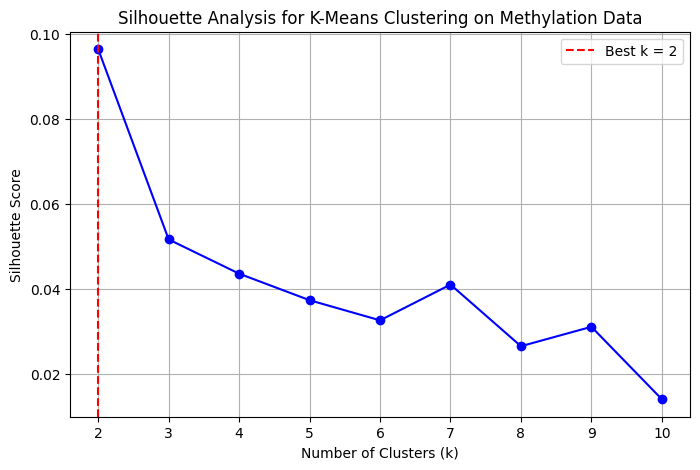

In [18]:
import matplotlib.pyplot as plt

# 3. Visualization of Silhouette Scores
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Analysis for K-Means Clustering on Methylation Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k = {best_k}')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# 4. Final K-Means Application
# ---------------------------------------------------------
print(f"\nApplying final K-means model with k = {best_k}...")
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Create a new column in the original dataframe to store the assigned clusters
df['Cluster_Label'] = final_kmeans.fit_predict(X)

# Display the first few rows to verify the cluster assignments
print("\nFinal Dataset Preview with Clusters:")
print(df.head())

# Optional: Save the clustered data to a new CSV file
# df.to_csv("methylation_lihc_pd_tumor_clustered.csv")


Applying final K-means model with k = 2...

Final Dataset Preview with Clusters:
                  cg00000108  cg00000109  cg00000236  cg00000292  cg00000321  \
TCGA-DD-A73D-01A    0.117137    0.924546    0.943050    0.657382    0.076094   
TCGA-G3-A5SK-01A    0.428748    0.908687    0.918806    0.676207    0.198359   
TCGA-DD-AAD8-01A    0.164315    0.802248    0.855616    0.719729    0.121652   
TCGA-WX-AA47-01A    0.259369    0.913790    0.931874    0.792509    0.083664   
TCGA-DD-A1EL-01A    0.619059    0.844312    0.866817    0.527882    0.198699   

                  cg00000363  cg00000622  cg00000658  cg00000714  cg00000721  \
TCGA-DD-A73D-01A    0.851907    0.014520    0.796828    0.408849    0.959089   
TCGA-G3-A5SK-01A    0.751913    0.014256    0.840600    0.167963    0.957603   
TCGA-DD-AAD8-01A    0.642324    0.011543    0.845569    0.113078    0.937181   
TCGA-WX-AA47-01A    0.800295    0.015096    0.822098    0.109717    0.947942   
TCGA-DD-A1EL-01A    0.709242    0.015